# US-08 - WAE-GAN Grid Search para Deteccao de Anomalias

**Objetivo:** testar varios hiperparametros do `WAEGAN`, selecionar o melhor conjunto pela validacao e depois avaliar o melhor modelo no conjunto de teste.

**Criterio de selecao:** `val_f1` com desempate por `val_auc_roc`, `val_average_precision` e `best_monitor`.

**Observacao:** o teste e usado apenas no fim, depois da escolha do melhor conjunto na validacao.

## 1. Setup

In [1]:
import json
import sys
import time
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import roc_curve

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation import compute_anomaly_metrics
from src.models.wae_gan import WAEGAN, WAEGANConfig
from src.preprocessing import make_waegan_anomaly_splits, to_sequence_last

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Project root:', PROJECT_ROOT)
print('Device:', DEVICE)
print('Torch:', torch.__version__)
if torch.cuda.is_available():
    print('CUDA:', torch.version.cuda)
    print('GPU:', torch.cuda.get_device_name(0))

c:\implementations\anomaly_detection_comparison\anomaly_detection_models_comparison\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: c:\implementations\anomaly_detection_comparison\anomaly_detection_models_comparison
Device: cuda
Torch: 2.11.0+cu128
CUDA: 12.8
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


## 2. Carregar Dados

In [2]:
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
GRIDSEARCH_DIR = PROJECT_ROOT / 'docs' / 'gridsearch'
FIGURES_DIR = PROJECT_ROOT / 'docs' / 'figures'

MODELS_DIR.mkdir(parents=True, exist_ok=True)
GRIDSEARCH_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

X_train = np.load(DATA_DIR / 'X_train.npy')
y_train = np.load(DATA_DIR / 'y_train.npy')
X_val = np.load(DATA_DIR / 'X_val.npy')
y_val = np.load(DATA_DIR / 'y_val.npy')
X_test = np.load(DATA_DIR / 'X_test.npy')
y_test = np.load(DATA_DIR / 'y_test.npy')

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val:  ', X_val.shape, 'y_val:  ', y_val.shape)
print('X_test: ', X_test.shape, 'y_test: ', y_test.shape)

X_train: (9720, 9, 4096) y_train: (9720,)
X_val:   (1944, 9, 4096) y_val:   (1944,)
X_test:  (2916, 9, 4096) y_test:  (2916,)


## 3. Parametros do Grid Search

In [ ]:
NORMAL_LABEL = 0
THRESHOLD_MULTIPLIER = 1.5

# Parametros fixos
BASE_PARAMS = {
    'dropout': 0.1,
    'tcn_kernel': 3,
    'disc_layers': 2,
    'lr': 1e-4,
    'disc_lr': 1e-4,
    'disc_steps': 1,
    'batch_size': 64,
    'epochs': 50,
    'early_stopping_patience': 5,
    'early_stopping_min_delta': 0.0,
    'sigma_z': 1.0,
}


PARAM_GRID = {
        'embedding_dim': [16, 32],
        'encoder_layers': [2, 3],
        'dropout': [0.0, 0.1],
        'tcn_hidden': [32, 64],
        'disc_hidden': [16, 32],
        'lr': [1e-4, 3e-4],
        'batch_size': [32, 64],
        'wae_regularization_term': [5.0, 10.0]
}

FINAL_EPOCHS = 50
BEST_MODEL_PATH = MODELS_DIR / 'wae_gan_gridsearch_best.pt'
RESULTS_CSV_PATH = GRIDSEARCH_DIR / '07_wae_gan_gridsearch_results.csv'
BEST_CONFIG_JSON_PATH = GRIDSEARCH_DIR / '07_wae_gan_gridsearch_best_config.json'

n_trials = int(np.prod([len(values) for values in PARAM_GRID.values()]))
print('Numero de combinacoes:', n_trials)
display(pd.DataFrame([BASE_PARAMS]).T.rename(columns={0: 'valor_fixo'}))
display(pd.DataFrame(dict((k, pd.Series(v)) for k, v in PARAM_GRID.items())))

Numero de combinacoes: 256


,valor_fixo
dropout,0.1000
tcn_kernel,3.0000
disc_layers,2.0000
lr,0.0001
disc_lr,0.0001
disc_steps,1.0000
batch_size,64.0000
epochs,30.0000
early_stopping_patience,5.0000
early_stopping_min_delta,0.0000


,embedding_dim,encoder_layers,dropout,tcn_hidden,disc_hidden,lr,batch_size,wae_regularization_term
0,16,2,0.0,32,16,0.0001,32,5.0
1,32,3,0.1,64,32,0.0003,64,10.0


## 4. Preparar Splits para Treino, Validacao e Teste

In [4]:
splits = make_waegan_anomaly_splits(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    normal_label=NORMAL_LABEL,
)

X_train_normal = splits['X_train_normal']
X_val_normal = splits['X_val_normal']
X_val_seq = to_sequence_last(X_val)
y_val_binary = (np.asarray(y_val) != NORMAL_LABEL).astype(np.int64)
X_test_seq = splits['X_test']
y_test_binary = splits['y_test_binary']

print('X_train_normal:', X_train_normal.shape)
print('X_val_normal:  ', X_val_normal.shape)
print('X_val_seq:     ', X_val_seq.shape)
print('X_test_seq:    ', X_test_seq.shape)
print('Anomalias na validacao:', int(y_val_binary.sum()), 'de', len(y_val_binary))
print('Anomalias no teste:', int(y_test_binary.sum()), 'de', len(y_test_binary))

X_train_normal: (2430, 4096, 9)
X_val_normal:   (486, 4096, 9)
X_val_seq:      (1944, 4096, 9)
X_test_seq:     (2916, 4096, 9)
Anomalias na validacao: 1458 de 1944
Anomalias no teste: 2187 de 2916


## 5. Grid Search

In [5]:
def iter_grid(param_grid):
    keys = list(param_grid.keys())
    for values in product(*(param_grid[key] for key in keys)):
        yield dict(zip(keys, values))


def build_config(search_params, *, epochs=None):
    config_kwargs = dict(BASE_PARAMS)
    config_kwargs.update(search_params)
    if epochs is not None:
        config_kwargs['epochs'] = epochs
    config_kwargs['n_features'] = X_train_normal.shape[2]
    config_kwargs['device'] = str(DEVICE)
    return WAEGANConfig(**config_kwargs)


def evaluate_candidate(search_params, trial_id):
    config = build_config(search_params)
    model = WAEGAN(config)
    n_params = sum(p.numel() for p in model.model.parameters() if p.requires_grad)

    t_start = time.time()
    model.fit(train_data=X_train_normal, validation_data=X_val_normal, verbose=False)
    train_time_s = time.time() - t_start

    train_scores = model.predict_anomaly_score(data=X_train_normal)
    val_scores = model.predict_anomaly_score(data=X_val_seq)
    threshold = model.calculate_threshold(train_scores, multiplier=THRESHOLD_MULTIPLIER)
    val_metrics = compute_anomaly_metrics(y_val_binary, val_scores, threshold=threshold)

    result = {
        'trial_id': trial_id,
        'n_params': n_params,
        'train_time_s': train_time_s,
        'best_epoch': model.best_epoch_,
        'best_monitor': model.best_monitor_value_,
        'stopped_epoch': model.stopped_epoch_,
        'threshold': threshold,
        'val_auc_roc': val_metrics['auc_roc'],
        'val_average_precision': val_metrics['average_precision'],
        'val_accuracy': val_metrics['accuracy'],
        'val_precision': val_metrics['precision'],
        'val_recall': val_metrics['recall'],
        'val_f1': val_metrics['f1'],
    }
    result.update(search_params)
    return model, result


results = []
best_model = None
best_result = None
best_score = None

for trial_id, search_params in enumerate(iter_grid(PARAM_GRID), start=1):
    print(f'Trial {trial_id}/{n_trials} -> {search_params}')
    model, result = evaluate_candidate(search_params, trial_id)
    results.append(result)

    score = (
        result['val_f1'],
        result['val_auc_roc'],
        result['val_average_precision'],
        -(result['best_monitor'] if result['best_monitor'] is not None else float('inf')),
    )

    if best_score is None or score > best_score:
        best_score = score
        best_result = dict(result)
        best_model = model

results_df = pd.DataFrame(results).sort_values(
    by=['val_f1', 'val_auc_roc', 'val_average_precision', 'best_monitor'],
    ascending=[False, False, False, True],
).reset_index(drop=True)

results_df.to_csv(RESULTS_CSV_PATH, index=False)
with open(BEST_CONFIG_JSON_PATH, 'w', encoding='utf-8') as fp:
    json.dump(best_result, fp, indent=2)

print('Resultados salvos em:', RESULTS_CSV_PATH.relative_to(PROJECT_ROOT))
print('Melhor configuracao salva em:', BEST_CONFIG_JSON_PATH.relative_to(PROJECT_ROOT))
display(results_df.head(10))

Trial 1/256 -> {'embedding_dim': 16, 'encoder_layers': 2, 'dropout': 0.0, 'tcn_hidden': 32, 'disc_hidden': 16, 'lr': 0.0001, 'batch_size': 32, 'wae_regularization_term': 5.0}


c:\implementations\anomaly_detection_comparison\anomaly_detection_models_comparison\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Trial 2/256 -> {'embedding_dim': 16, 'encoder_layers': 2, 'dropout': 0.0, 'tcn_hidden': 32, 'disc_hidden': 16, 'lr': 0.0001, 'batch_size': 32, 'wae_regularization_term': 10.0}


c:\implementations\anomaly_detection_comparison\anomaly_detection_models_comparison\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Trial 3/256 -> {'embedding_dim': 16, 'encoder_layers': 2, 'dropout': 0.0, 'tcn_hidden': 32, 'disc_hidden': 16, 'lr': 0.0001, 'batch_size': 64, 'wae_regularization_term': 5.0}


...

c:\implementations\anomaly_detection_comparison\anomaly_detection_models_comparison\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Trial 256/256 -> {'embedding_dim': 32, 'encoder_layers': 3, 'dropout': 0.1, 'tcn_hidden': 64, 'disc_hidden': 32, 'lr': 0.0003, 'batch_size': 64, 'wae_regularization_term': 10.0}


c:\implementations\anomaly_detection_comparison\anomaly_detection_models_comparison\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Resultados salvos em: docs\gridsearch\07_wae_gan_gridsearch_results.csv
Melhor configuracao salva em: docs\gridsearch\07_wae_gan_gridsearch_best_config.json


,trial_id,n_params,train_time_s,best_epoch,best_monitor,stopped_epoch,threshold,val_auc_roc,val_average_precision,val_accuracy,...,val_recall,val_f1,embedding_dim,encoder_layers,dropout,tcn_hidden,disc_hidden,lr,batch_size,wae_regularization_term
0,151,94458,127.124824,19,3.465477,24.0,0.043499,1.000000,1.0,0.999486,...,1.0,0.999657,32,2,0.0,64,16,0.0003,64,5.0
1,133,30458,109.504107,16,3.469994,21.0,0.035457,1.000000,1.0,0.999486,...,1.0,0.999657,32,2,0.0,32,16,0.0003,32,5.0
2,230,43258,123.488186,13,6.907865,18.0,0.125508,1.000000,1.0,0.999486,...,1.0,0.999657,32,3,0.1,32,16,0.0003,32,10.0
3,149,94458,108.276627,12,3.458159,17.0,0.018353,0.999999,1.0,0.999486,...,1.0,0.999657,32,2,0.0,64,16,0.0003,32,5.0
4,186,105994,147.763829,13,6.654761,18.0,0.255796,0.999999,1.0,0.999486,...,1.0,0.999657,32,2,0.1,64,32,0.0001,32,10.0
5,157,105994,100.589686,10,3.364496,15.0,0.064762,1.000000,1.0,0.998971,...,1.0,0.999315,32,2,0.0,64,32,0.0003,32,5.0
6,143,41994,83.223952,17,3.377988,22.0,0.119646,1.000000,1.0,0.998971,...,1.0,0.999315,32,2,0.0,32,32,0.0003,64,5.0
7,127,148986,94.613372,7,3.397637,12.0,0.250843,1.000000,1.0,0.998971,...,1.0,0.999315,16,3,0.1,64,32,0.0003,64,5.0
8,23,88298,111.612630,9,3.413806,14.0,0.093653,1.000000,1.0,0.998971,...,1.0,0.999315,16,2,0.0,64,16,0.0003,64,5.0
9,135,30458,92.215562,21,3.424913,26.0,0.066337,1.000000,1.0,0.998971,...,1.0,0.999315,32,2,0.0,32,16,0.0003,64,5.0


## 6. Re-treinar o Melhor Conjunto e Salvar Checkpoint Final

In [6]:
best_search_params = {key: best_result[key] for key in PARAM_GRID.keys()}
best_final_config = build_config(best_search_params, epochs=FINAL_EPOCHS)
final_model = WAEGAN(best_final_config)

final_t_start = time.time()
final_model.fit(train_data=X_train_normal, validation_data=X_val_normal, verbose=True)
final_train_time_s = time.time() - final_t_start

final_model.save(BEST_MODEL_PATH)
print('Checkpoint salvo em:', BEST_MODEL_PATH.relative_to(PROJECT_ROOT))
print('Tempo de treino final (s):', round(final_train_time_s, 2))
print('Best epoch:', final_model.best_epoch_)
print('Best monitor:', final_model.best_monitor_value_)
print('Stopped epoch:', final_model.stopped_epoch_)

c:\implementations\anomaly_detection_comparison\anomaly_detection_models_comparison\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Epoch 1/50 | loss_D=1.437575 | loss_G=4.632142 | val_G=4.213591
Epoch 2/50 | loss_D=1.455048 | loss_G=4.144317 | val_G=4.094367
Epoch 3/50 | loss_D=1.440542 | loss_G=4.070307 | val_G=4.050699
Epoch 4/50 | loss_D=1.424809 | loss_G=4.027731 | val_G=4.006617
Epoch 5/50 | loss_D=1.412442 | loss_G=3.982111 | val_G=3.960056
Epoch 6/50 | loss_D=1.403136 | loss_G=3.940460 | val_G=3.924502
Epoch 7/50 | loss_D=1.395928 | loss_G=3.900623 | val_G=3.874534
Epoch 8/50 | loss_D=1.391671 | loss_G=3.855240 | val_G=3.844773
Epoch 9/50 | loss_D=1.381198 | loss_G=3.848859 | val_G=3.846117
Epoch 10/50 | loss_D=1.381688 | loss_G=3.778222 | val_G=3.711004
Epoch 11/50 | loss_D=1.391887 | loss_G=3.664028 | val_G=3.624078
Epoch 12/50 | loss_D=1.396214 | loss_G=3.602214 | val_G=3.584476
Epoch 13/50 | loss_D=1.394429 | loss_G=3.583225 | val_G=3.570751
Epoch 14/50 | loss_D=1.395428 | loss_G=3.560360 | val_G=3.556065
Epoch 15/50 | loss_D=1.397094 | loss_G=3.547225 | val_G=3.551538
Epoch 16/50 | loss_D=1.395819 | lo

## 7. Avaliar o Melhor Modelo na Validacao e no Teste

In [7]:
best_model = WAEGAN.load(BEST_MODEL_PATH, map_location=str(DEVICE))

train_scores = best_model.predict_anomaly_score(data=X_train_normal)
val_scores = best_model.predict_anomaly_score(data=X_val_seq)
test_scores = best_model.predict_anomaly_score(data=X_test_seq)

threshold = best_model.calculate_threshold(train_scores, multiplier=THRESHOLD_MULTIPLIER)
val_metrics = compute_anomaly_metrics(y_val_binary, val_scores, threshold=threshold)
test_metrics = compute_anomaly_metrics(y_test_binary, test_scores, threshold=threshold)

summary_df = pd.DataFrame([
    {
        'split': 'validation',
        'auc_roc': val_metrics['auc_roc'],
        'average_precision': val_metrics['average_precision'],
        'accuracy': val_metrics['accuracy'],
        'precision': val_metrics['precision'],
        'recall': val_metrics['recall'],
        'f1': val_metrics['f1'],
        'threshold': threshold,
    },
    {
        'split': 'test',
        'auc_roc': test_metrics['auc_roc'],
        'average_precision': test_metrics['average_precision'],
        'accuracy': test_metrics['accuracy'],
        'precision': test_metrics['precision'],
        'recall': test_metrics['recall'],
        'f1': test_metrics['f1'],
        'threshold': threshold,
    },
])

best_hparams_df = pd.DataFrame([
    {
        **best_search_params,
        'dropout': BASE_PARAMS['dropout'],
        'tcn_kernel': BASE_PARAMS['tcn_kernel'],
        'disc_layers': BASE_PARAMS['disc_layers'],
        'lr': BASE_PARAMS['lr'],
        'disc_lr': BASE_PARAMS['disc_lr'],
        'disc_steps': BASE_PARAMS['disc_steps'],
        'batch_size': BASE_PARAMS['batch_size'],
        'search_epochs': BASE_PARAMS['epochs'],
        'final_epochs': FINAL_EPOCHS,
        'patience': BASE_PARAMS['early_stopping_patience'],
        'sigma_z': BASE_PARAMS['sigma_z'],
        'best_epoch_final': best_model.best_epoch_,
        'best_monitor_final': best_model.best_monitor_value_,
    }
])

print('Threshold final:', threshold)
display(best_hparams_df)
display(summary_df)

Threshold final: 0.048709215596318245


,embedding_dim,encoder_layers,dropout,tcn_hidden,disc_hidden,lr,batch_size,wae_regularization_term,tcn_kernel,disc_layers,disc_lr,disc_steps,search_epochs,final_epochs,patience,sigma_z,best_epoch_final,best_monitor_final
0,32,2,0.1,64,16,0.0001,64,5.0,3,2,0.0001,1,30,50,5,1.0,15,3.551538


,split,auc_roc,average_precision,accuracy,precision,recall,f1,threshold
0,validation,1.0,1.0,0.997942,0.997264,1.0,0.998630,0.048709
1,test,1.0,1.0,0.995542,0.994091,1.0,0.997037,0.048709


## 8. Visualizar os Melhores Resultados do Grid

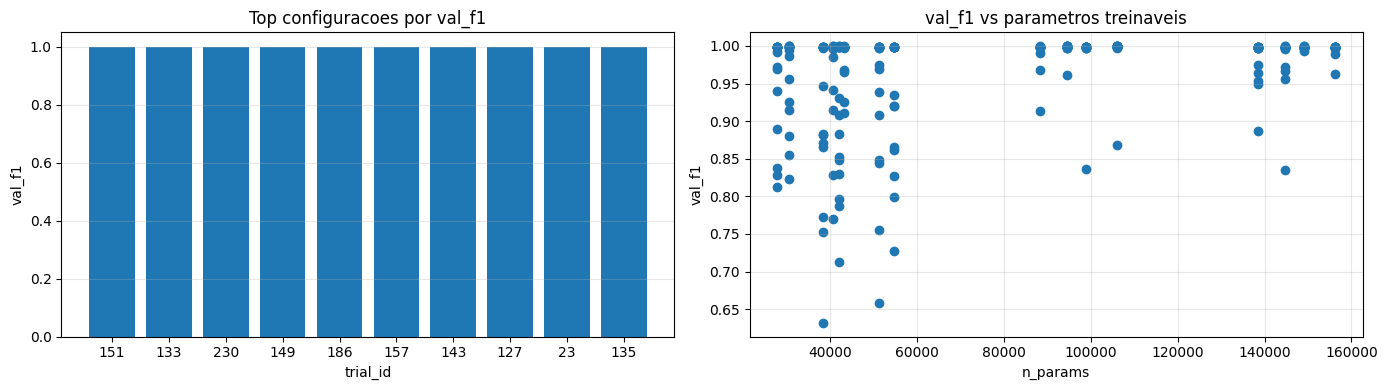

Saved: docs\figures\07_wae_gan_gridsearch_summary.png


In [8]:
top_k = min(10, len(results_df))
top_df = results_df.head(top_k).copy()
top_df['label'] = top_df['trial_id'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(top_df['label'], top_df['val_f1'])
axes[0].set_title('Top configuracoes por val_f1')
axes[0].set_xlabel('trial_id')
axes[0].set_ylabel('val_f1')
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].scatter(results_df['n_params'], results_df['val_f1'])
axes[1].set_title('val_f1 vs parametros treinaveis')
axes[1].set_xlabel('n_params')
axes[1].set_ylabel('val_f1')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_path = FIGURES_DIR / '07_wae_gan_gridsearch_summary.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', save_path.relative_to(PROJECT_ROOT))

## 9. ROC e Distribuicao de Scores do Melhor Modelo

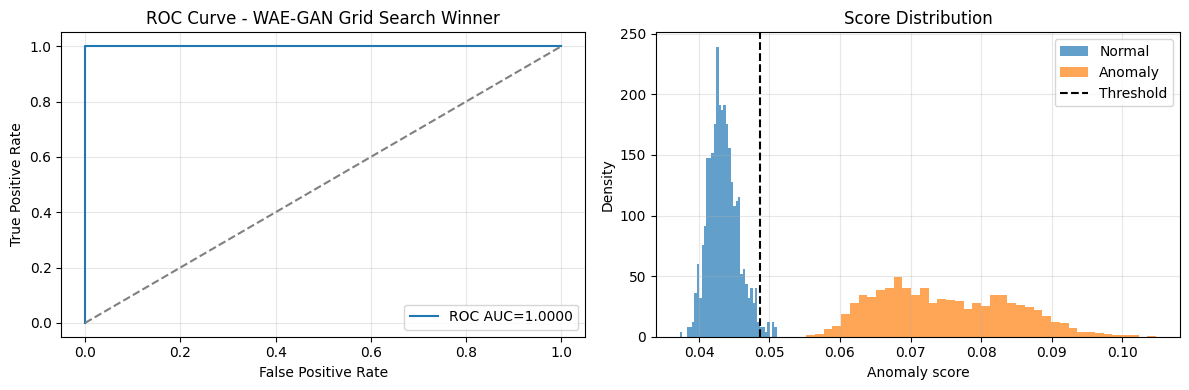

Saved: docs\figures\07_wae_gan_gridsearch_scores.png


In [9]:
fpr, tpr, _ = roc_curve(y_test_binary, test_scores)
normal_scores = test_scores[y_test_binary == 0]
anomaly_scores = test_scores[y_test_binary == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(fpr, tpr, label=f"ROC AUC={test_metrics['auc_roc']:.4f}")
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('ROC Curve - WAE-GAN Grid Search Winner')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(normal_scores, bins=40, alpha=0.7, label='Normal', density=True)
axes[1].hist(anomaly_scores, bins=40, alpha=0.7, label='Anomaly', density=True)
axes[1].axvline(threshold, color='black', linestyle='--', label='Threshold')
axes[1].set_title('Score Distribution')
axes[1].set_xlabel('Anomaly score')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_path = FIGURES_DIR / '07_wae_gan_gridsearch_scores.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', save_path.relative_to(PROJECT_ROOT))

## 10. Artefatos Gerados

- `models/wae_gan_gridsearch_best.pt`
- `docs/gridsearch/07_wae_gan_gridsearch_results.csv`
- `docs/gridsearch/07_wae_gan_gridsearch_best_config.json`
- `docs/figures/07_wae_gan_gridsearch_summary.png`
- `docs/figures/07_wae_gan_gridsearch_scores.png`